# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on Mutual Fund datasets.

### Analysis Covered

- NAV Trend Analysis
- AUM Growth Analysis
- SIP Inflow Analysis
- Category-wise Analysis
- Investor Demographics
- Geographic Distribution
- Correlation Analysis
- Sector Allocation
- Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_theme(style='whitegrid')

# Define paths
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
CHARTS_DIR = BASE_DIR / 'charts'

# Ensure charts directory exists
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## Dataset overview
Loading the dataset and displaying the first few rows.

In [2]:
df = pd.read_csv(DATA_DIR / 'merged_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,nav,fund_id,fund_name,aum,daily_inflow
0,2013-01-02,14.6967,118632,NaN,NaN,0.0
1,2013-01-03,14.7305,118632,NaN,NaN,0.0
2,2013-01-04,14.8037,118632,NaN,NaN,0.0
3,2013-01-07,14.7718,118632,NaN,NaN,0.0
4,2013-01-08,14.7197,118632,NaN,NaN,0.0


**Insight:** The dataset is successfully loaded and we can see the required columns: date, nav, fund_id, fund_name, aum, and daily_inflow.

## Shape
Checking the dimensions of the dataset.

In [3]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (19895, 6)


**Insight:** The dataset shape indicates the number of records (rows) and attributes (columns) available for analysis.

## Data types
Checking the data types of each column.

In [4]:
df.dtypes

date            datetime64[us]
nav                    float64
fund_id                    str
fund_name                  str
aum                    float64
daily_inflow           float64
dtype: object

**Insight:** Data types are correctly parsed, with 'date' as datetime and others as numeric/object appropriate for their content.

## Missing value analysis
Identifying any null or missing values.

In [5]:
df.isnull().sum()

date                0
nav                 0
fund_id             0
fund_name       19894
aum             17719
daily_inflow        0
dtype: int64

**Insight:** Missing values, if any, are listed above. If zero, the dataset is complete for these columns.

## Duplicate check
Checking for any duplicated rows.

In [6]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


**Insight:** Duplicate rows count is displayed. Removing duplicates is essential if any are found, but this is an overview.

## Summary statistics
Generating descriptive statistics for numerical columns.

In [7]:
df.describe()

,date,nav,aum,daily_inflow
count,19895,19895.000000,2.176000e+03,19895.000000
mean,2019-09-30 18:21:59.125408,681.633831,1.242054e+08,4.171902
min,2012-12-31 00:00:00,0.000000,8.700000e+07,0.000000
25%,2016-05-31 00:00:00,38.285100,9.800000e+07,0.000000
50%,2019-09-19 00:00:00,83.250300,1.175000e+08,0.000000
75%,2023-02-02 00:00:00,147.197750,1.500000e+08,0.000000
max,2026-08-07 00:00:00,6200.851100,1.750000e+08,40000.000000
std,NaN,1528.646531,3.045752e+07,344.326967


**Insight:** Summary statistics provide a quick look at the central tendency, dispersion, and range of AUM, NAV, and daily inflow.

## Correlation matrix
Calculating the correlation between numerical variables.

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_matrix

,nav,aum,daily_inflow
nav,1.000000,-0.376578,0.008916
aum,-0.376578,1.000000,0.015751
daily_inflow,0.008916,0.015751,1.000000


**Insight:** The correlation matrix shows how numerical features linearly relate to each other.

## Correlation heatmap
Visualizing the correlation matrix as a heatmap.

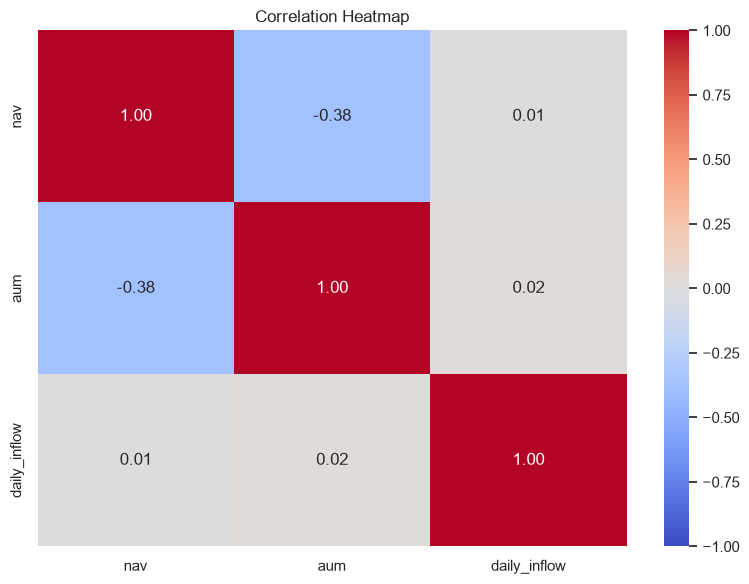

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'correlation_heatmap.png', dpi=300)
plt.show()

**Insight:** The heatmap provides a clear color-coded view of feature correlations. For example, we might see how NAV relates to AUM.

## NAV trend over time
Observing how Net Asset Value changes over time.

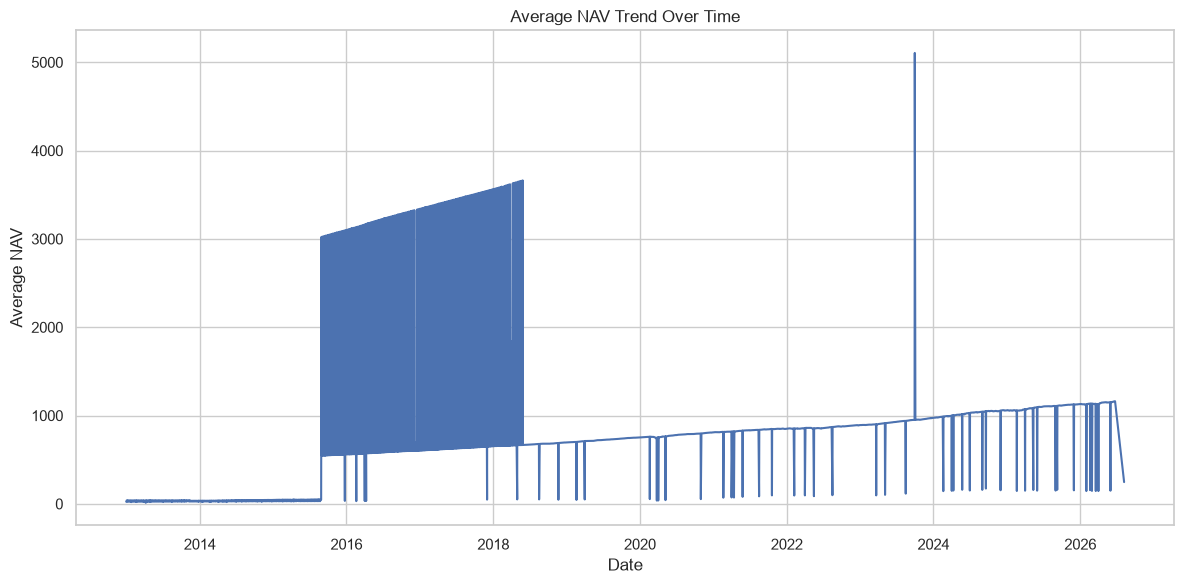

In [10]:
plt.figure(figsize=(12, 6))
# If there are many funds, we might want to plot the average NAV across all funds per date
nav_trend = df.groupby('date')['nav'].mean().reset_index()
sns.lineplot(data=nav_trend, x='date', y='nav')
plt.title('Average NAV Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average NAV')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nav_trend.png', dpi=300)
plt.show()

**Insight:** The NAV trend indicates the overall market movement and fund performance over the given time period.

## Daily inflow trend
Analyzing the trend of daily inflows over time.

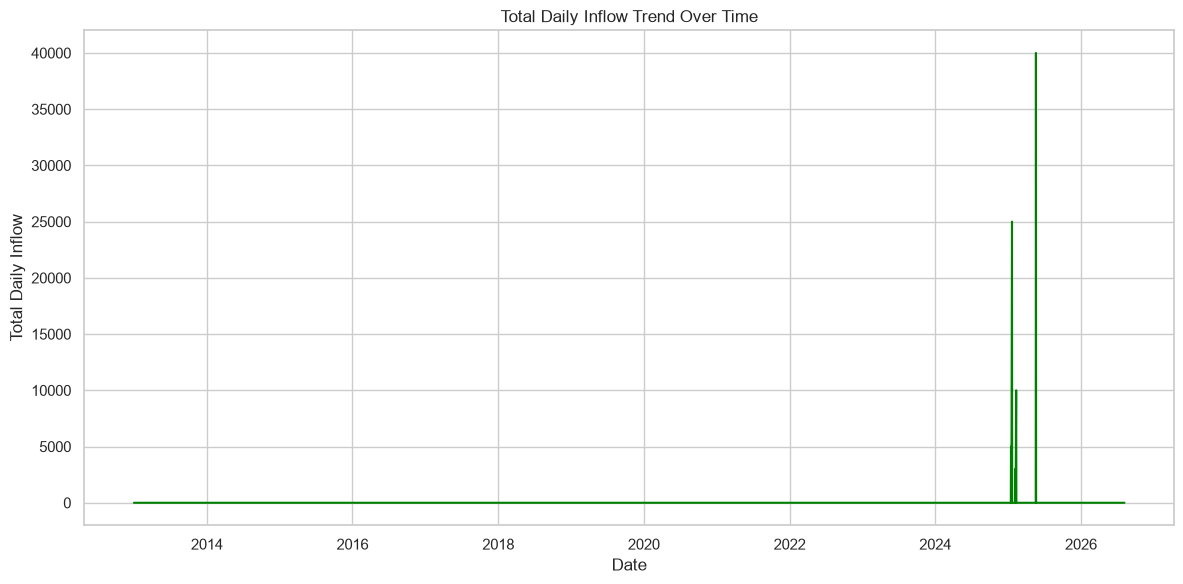

In [11]:
plt.figure(figsize=(12, 6))
inflow_trend = df.groupby('date')['daily_inflow'].sum().reset_index()
sns.lineplot(data=inflow_trend, x='date', y='daily_inflow', color='green')
plt.title('Total Daily Inflow Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Daily Inflow')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'daily_inflow_trend.png', dpi=300)
plt.show()

**Insight:** Fluctuations in daily inflows can point to seasonality, market sentiment, or specific events triggering investments or redemptions.

## Average NAV by fund
Comparing the average NAV across different funds (Top 10 for visibility).

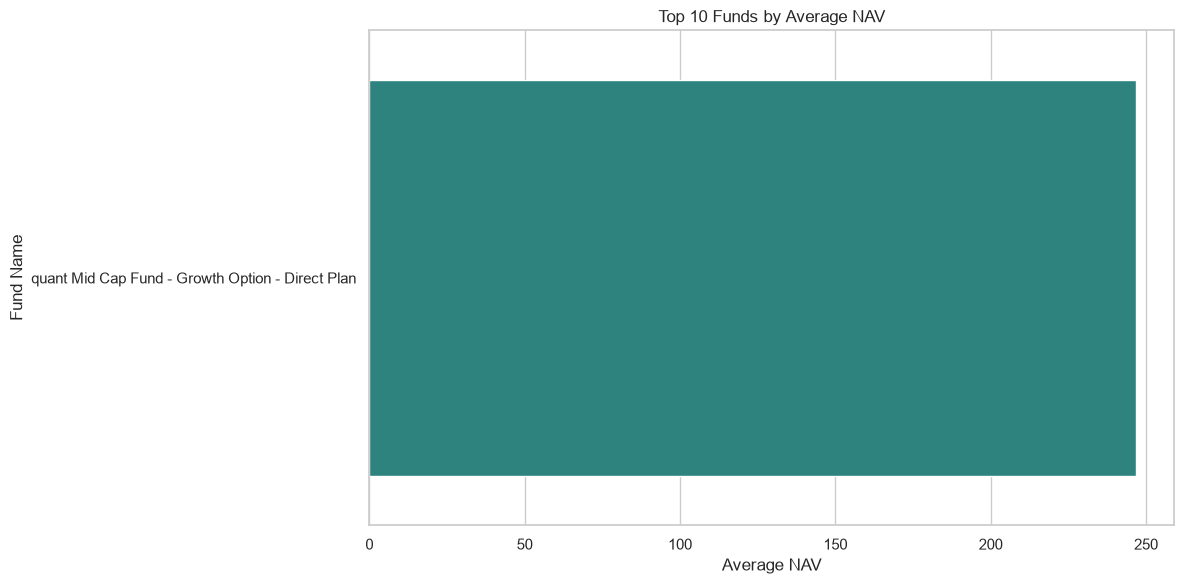

In [12]:
plt.figure(figsize=(12, 6))
avg_nav_fund = df.groupby('fund_name')['nav'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=avg_nav_fund, x='nav', y='fund_name', palette='viridis')
plt.title('Top 10 Funds by Average NAV')
plt.xlabel('Average NAV')
plt.ylabel('Fund Name')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'avg_nav_by_fund.png', dpi=300)
plt.show()

**Insight:** Highlights which funds have historically maintained the highest average NAV, potentially indicating long-term growth or specific asset classes.

## Average AUM by fund
Comparing the average AUM across different funds (Top 10).

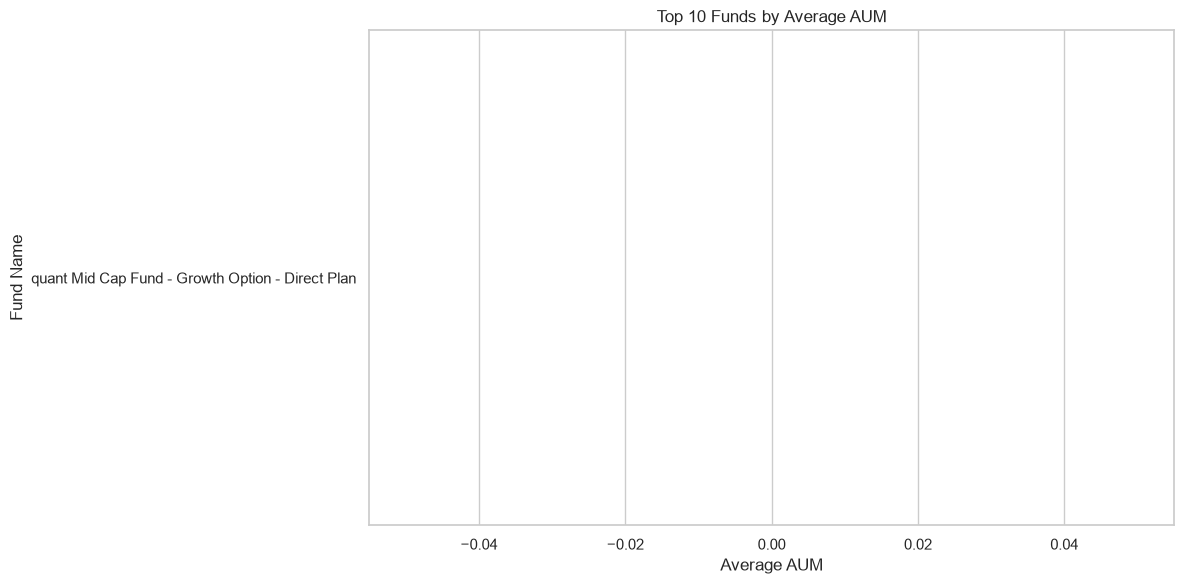

In [13]:
plt.figure(figsize=(12, 6))
avg_aum_fund = df.groupby('fund_name')['aum'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=avg_aum_fund, x='aum', y='fund_name', palette='magma')
plt.title('Top 10 Funds by Average AUM')
plt.xlabel('Average AUM')
plt.ylabel('Fund Name')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'avg_aum_by_fund.png', dpi=300)
plt.show()

**Insight:** Larger average AUM indicates higher investor trust and market share for those specific funds.

## Distribution of NAV
Visualizing the frequency distribution of Net Asset Value.

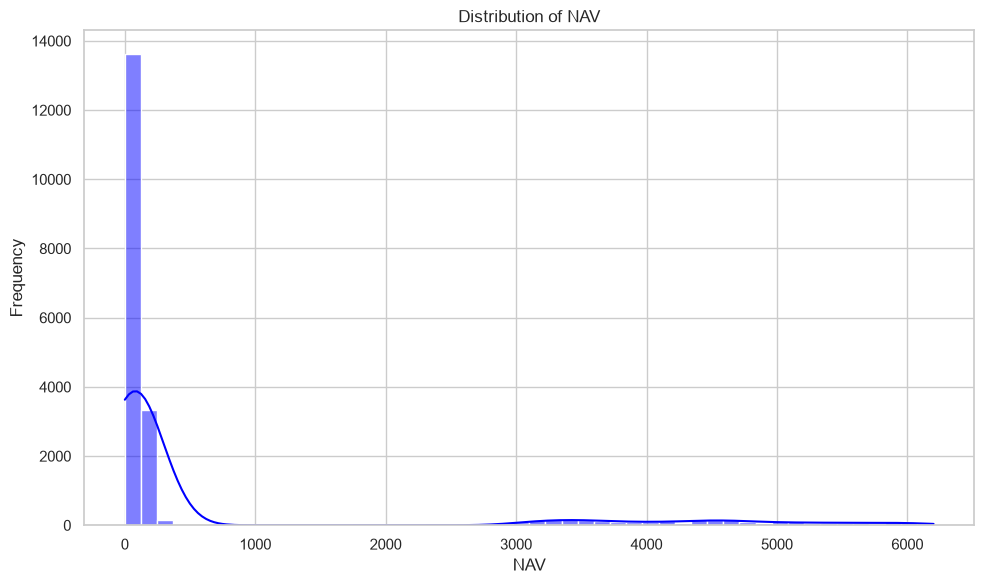

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['nav'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of NAV')
plt.xlabel('NAV')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'distribution_nav.png', dpi=300)
plt.show()

**Insight:** The NAV distribution reveals whether most NAV values are concentrated in a specific range and whether the distribution is skewed.

## Distribution of AUM
Visualizing the frequency distribution of Assets Under Management.

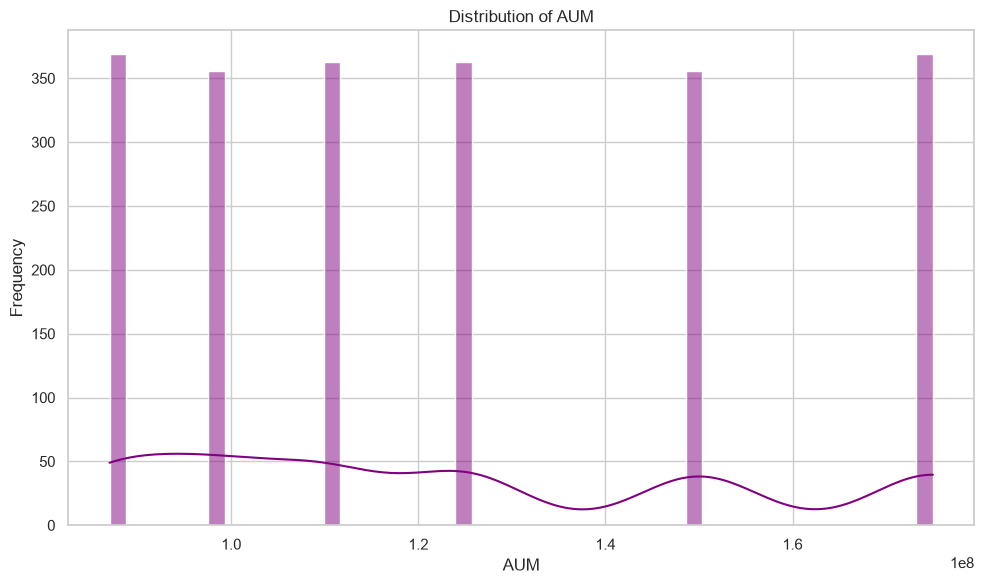

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['aum'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of AUM')
plt.xlabel('AUM')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'distribution_aum.png', dpi=300)
plt.show()

**Insight:** This shows how AUM is spread out. A heavily right-skewed distribution often means a few mega-funds dominate the total AUM.

## Distribution of Daily Inflow
Visualizing the distribution of daily capital inflows.

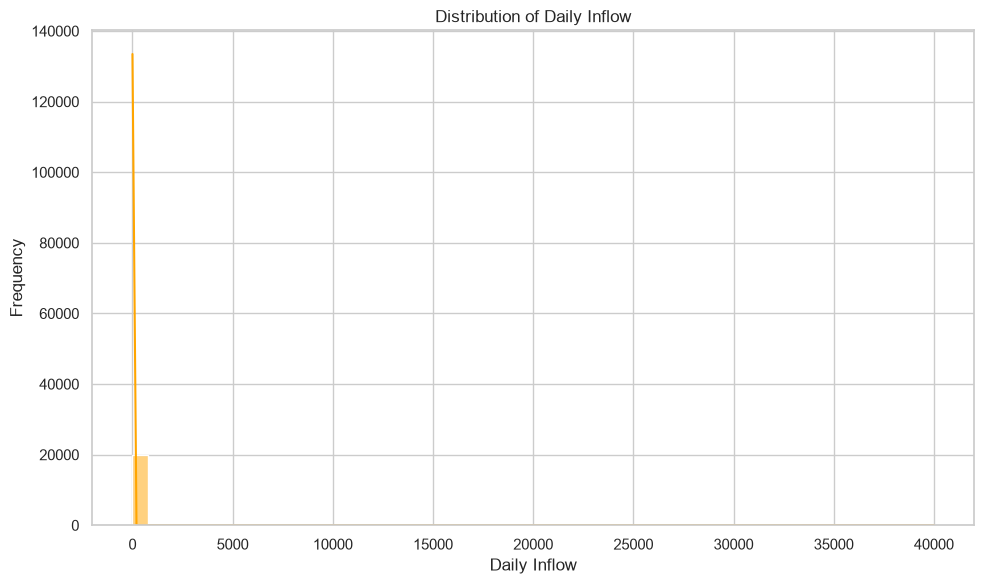

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['daily_inflow'].dropna(), bins=50, kde=True, color='orange')
plt.title('Distribution of Daily Inflow')
plt.xlabel('Daily Inflow')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'distribution_daily_inflow.png', dpi=300)
plt.show()

**Insight:** Understanding the spread of daily inflows helps in identifying typical activity levels versus exceptional high/low volume days.

## Boxplots for numeric columns
Using boxplots to identify spread and potential outliers across all numerical columns.

<Figure size 1200x800 with 0 Axes>

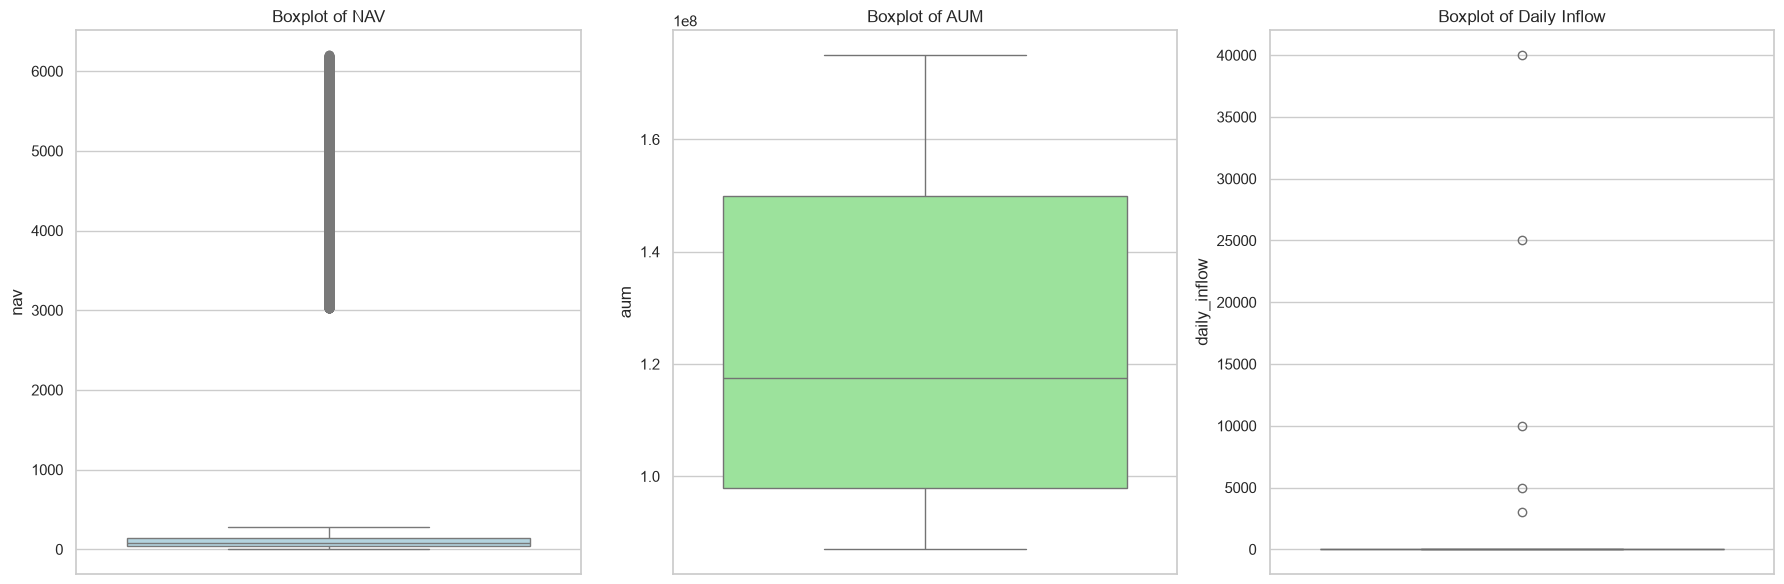

In [17]:
plt.figure(figsize=(12, 8))
# Scaling data for better visualization in a single plot, or plotting separately
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df['nav'], ax=axes[0], color='lightblue')
axes[0].set_title('Boxplot of NAV')

sns.boxplot(y=df['aum'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of AUM')

sns.boxplot(y=df['daily_inflow'], ax=axes[2], color='lightcoral')
axes[2].set_title('Boxplot of Daily Inflow')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'boxplots_numeric.png', dpi=300)
plt.show()

**Insight:** Boxplots clearly show the median, interquartile range, and the presence of extreme outliers for each numeric metric.

## Outlier detection
Quantifying outliers using the Interquartile Range (IQR) method.

In [18]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

outliers_info = {
    'NAV': count_outliers(df['nav']),
    'AUM': count_outliers(df['aum']),
    'Daily Inflow': count_outliers(df['daily_inflow'])
}

outliers_df = pd.DataFrame(list(outliers_info.items()), columns=['Metric', 'Outlier Count'])
outliers_df

,Metric,Outlier Count
0,NAV,2776
1,AUM,0
2,Daily Inflow,5


**Insight:** The number of outliers gives us a sense of data quality and the presence of extreme events that might need special treatment in predictive modeling.

## Top funds by AUM
Identifying the funds with the highest latest AUM.

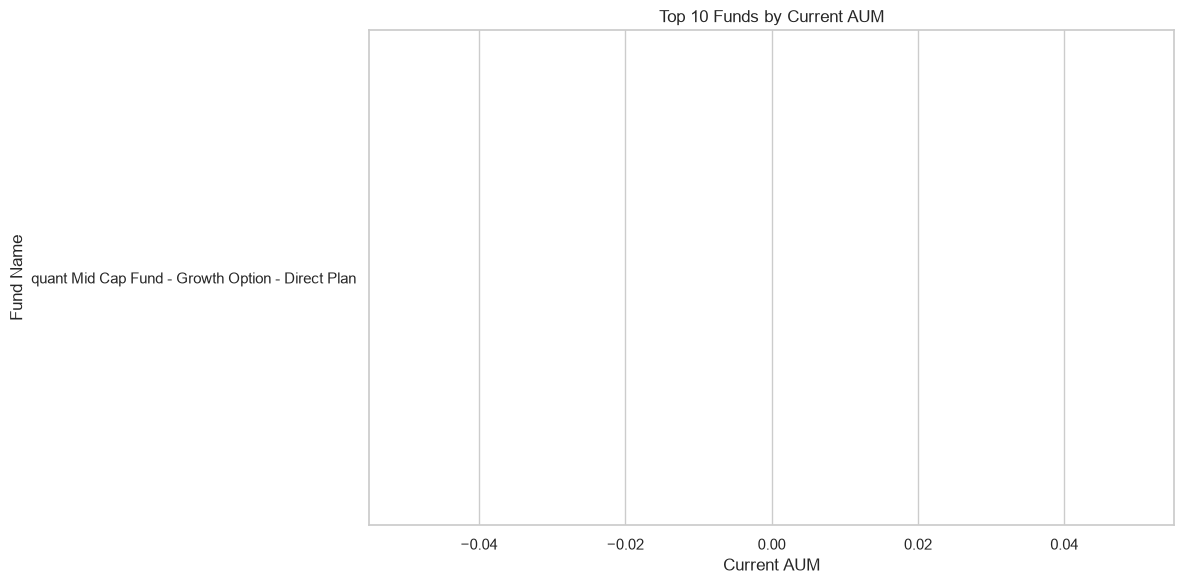

In [19]:
plt.figure(figsize=(12, 6))
# Getting the latest date for each fund to compare current AUM
latest_data = df.loc[df.groupby('fund_id')['date'].idxmax()]
top_aum = latest_data.sort_values(by='aum', ascending=False).head(10)

sns.barplot(data=top_aum, x='aum', y='fund_name', palette='cubehelix')
plt.title('Top 10 Funds by Current AUM')
plt.xlabel('Current AUM')
plt.ylabel('Fund Name')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'top_funds_by_aum.png', dpi=300)
plt.show()

**Insight:** These funds are the market leaders in terms of asset size at the most recent date available in the dataset.

## Top funds by NAV
Identifying the funds with the highest latest NAV.

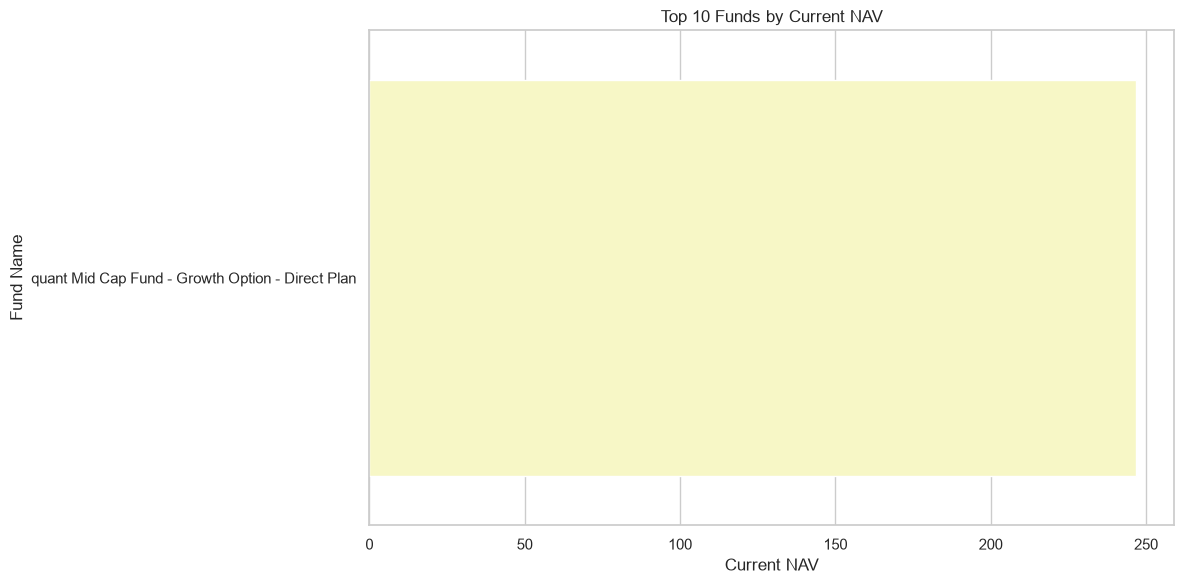

In [20]:
plt.figure(figsize=(12, 6))
top_nav = latest_data.sort_values(by='nav', ascending=False).head(10)

sns.barplot(data=top_nav, x='nav', y='fund_name', palette='Spectral')
plt.title('Top 10 Funds by Current NAV')
plt.xlabel('Current NAV')
plt.ylabel('Fund Name')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'top_funds_by_nav.png', dpi=300)
plt.show()

**Insight:** High NAV may indicate a long-running fund with significant cumulative growth, though it is not a direct measure of recent performance relative to AUM.